In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("Leads Reales Limpio.csv", encoding="utf-8-sig")
df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,2,543,108,33,0,1,389,1,12,3.1,72.0
1,2024,6,967,140,173,31,3,620,17,6,1.0,64.0
2,2024,7,954,112,251,12,9,570,5,21,3.7,60.0
3,2025,2,561,9,39,14,31,468,150,20,4.3,83.0
4,2025,3,925,39,98,3,54,731,125,30,4.1,79.0


In [3]:
columnas_leads = ["Total", "Ilocalizable", "No Contesta", "D. Incorrectos",
                  "Duplicados", "Efectivos", "Abiertos", "Ventas"]

df[columnas_leads].head()

,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas
0,543,108,33,0,1,389,1,12
1,967,140,173,31,3,620,17,6
2,954,112,251,12,9,570,5,21
3,561,9,39,14,31,468,150,20
4,925,39,98,3,54,731,125,30


In [4]:
correlaciones = df[columnas_leads].corr()
correlaciones

,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas
Total,1.000000,0.682058,0.339954,0.654584,0.354193,0.820418,0.819765,0.608402
Ilocalizable,0.682058,1.000000,-0.058750,0.745128,-0.086091,0.390606,0.517175,0.056782
No Contesta,0.339954,-0.058750,1.000000,-0.097234,0.049044,0.282912,0.086850,0.435561
D. Incorrectos,0.654584,0.745128,-0.097234,1.000000,-0.073191,0.284704,0.598829,0.073796
Duplicados,0.354193,-0.086091,0.049044,-0.073191,1.000000,0.666081,0.244164,0.436867
Efectivos,0.820418,0.390606,0.282912,0.284704,0.666081,1.000000,0.548536,0.605586
Abiertos,0.819765,0.517175,0.086850,0.598829,0.244164,0.548536,1.000000,0.646575
Ventas,0.608402,0.056782,0.435561,0.073796,0.436867,0.605586,0.646575,1.000000


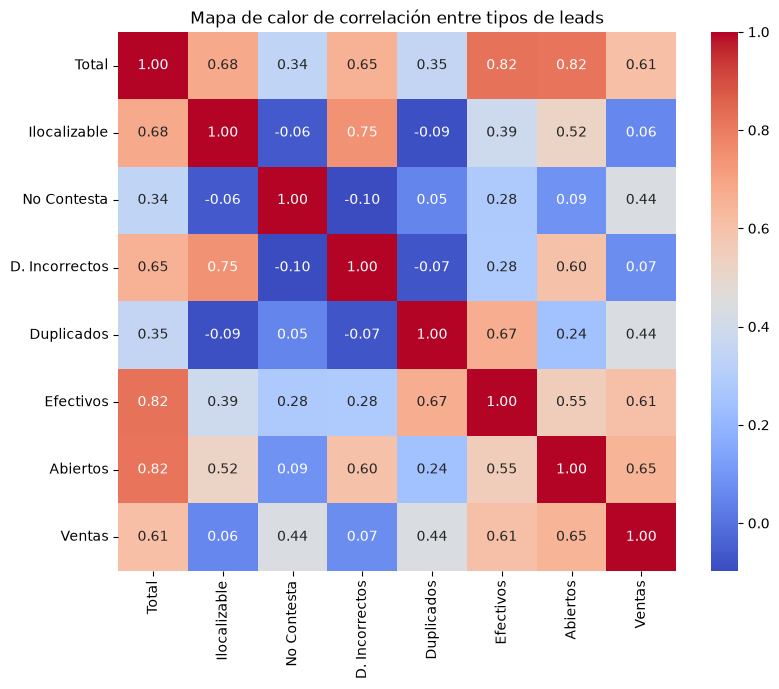

In [5]:
plt.figure(figsize=(9, 7))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de calor de correlación entre tipos de leads")
plt.show()

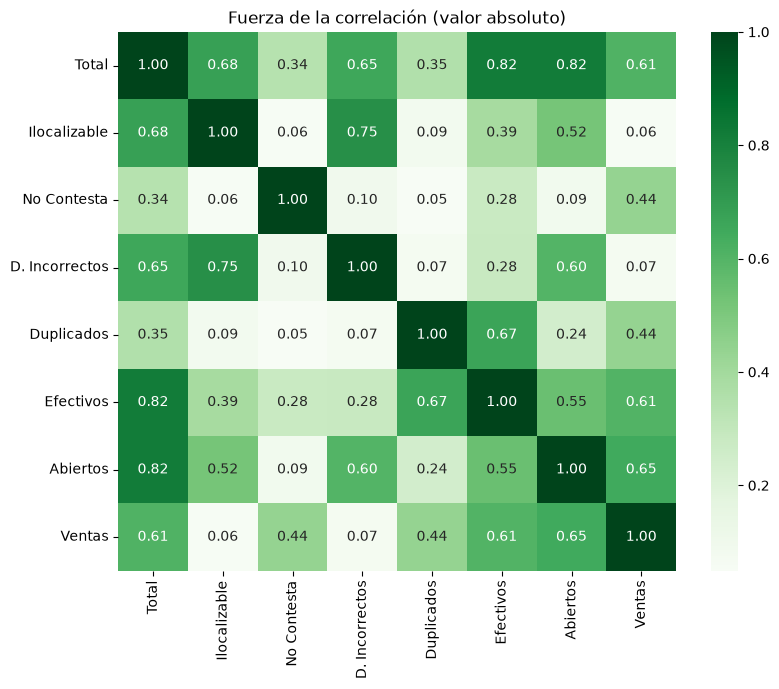

In [6]:
correlaciones_abs = correlaciones.abs()

plt.figure(figsize=(9, 7))
sns.heatmap(correlaciones_abs, annot=True, fmt=".2f", cmap="Greens")
plt.title("Fuerza de la correlación (valor absoluto)")
plt.show()

In [7]:
corr_ventas = correlaciones_abs["Ventas"].drop("Ventas").sort_values(ascending=False)
corr_ventas

Abiertos          0.646575
Total             0.608402
Efectivos         0.605586
Duplicados        0.436867
No Contesta       0.435561
D. Incorrectos    0.073796
Ilocalizable      0.056782
Name: Ventas, dtype: float64

In [8]:
mejor_predictor = corr_ventas.index[0]      # el nombre del tipo de lead
valor_corr = corr_ventas.iloc[0]            # su correlación con Ventas

print("Mejor predictor de 'Ventas' según el heat map:", mejor_predictor)
print("Correlación con 'Ventas':", round(valor_corr, 2))

Mejor predictor de 'Ventas' según el heat map: Abiertos
Correlación con 'Ventas': 0.65


In [9]:
if valor_corr >= 0.7:
    fuerza = "FUERTE"
    comentario = "conviene hacer la regresión, el modelo debería explicar bien las Ventas."
elif valor_corr >= 0.5:
    fuerza = "MODERADA"
    comentario = "se puede hacer la regresión, pero el modelo explicará las Ventas solo en parte."
else:
    fuerza = "DEBIL"
    comentario = "la regresión explicará muy poco; es el mejor predictor disponible, pero es flojo."

print(f"La correlacion entre '{mejor_predictor}' y 'Ventas' es {fuerza} ({valor_corr:.2f}).")
print("Conclusion:", comentario)

La correlacion entre 'Abiertos' y 'Ventas' es MODERADA (0.65).
Conclusion: se puede hacer la regresión, pero el modelo explicará las Ventas solo en parte.


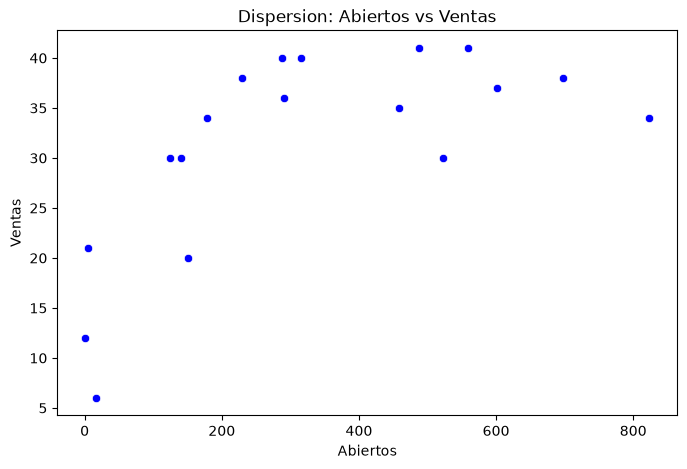

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=mejor_predictor, y="Ventas", data=df, color="blue")
plt.title(f"Dispersion: {mejor_predictor} vs Ventas")
plt.show()

In [11]:
Vars_Indep = df[[mejor_predictor]]
Var_Dep = df["Ventas"]

In [12]:
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Abiertos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.57
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [13]:
pendiente = model.coef_[0]
ordenada = model.intercept_

print("Pendiente (m):", round(pendiente, 4))
print("Ordenada al origen (b):", round(ordenada, 4))
print(f"Ecuacion:  Ventas = {pendiente:.4f} * {mejor_predictor} + {ordenada:.4f}")

Pendiente (m): 0.0266
Ordenada al origen (b): 22.5718
Ecuacion:  Ventas = 0.0266 * Abiertos + 22.5718


In [14]:
coef_deter = model.score(X=Vars_Indep, y=Var_Dep)
coef_correl = np.sqrt(coef_deter)

print("R2 (determinacion):", round(coef_deter, 4))
print("r  (correlacion):  ", round(coef_correl, 4))

R2 (determinacion): 0.4181
r  (correlacion):   0.6466


In [15]:
y_pred = model.predict(X=Vars_Indep)
df["Ventas_Predichas"] = y_pred

df[[mejor_predictor, "Ventas", "Ventas_Predichas"]].head(10)

,Abiertos,Ventas,Ventas_Predichas
0,1,12,22.598420
1,17,6,23.024038
2,5,21,22.704825
3,150,20,26.561989
4,125,30,25.896960
5,141,30,26.322578
6,179,34,27.333421
7,315,40,30.951175
8,290,36,30.286147
9,229,38,28.663478


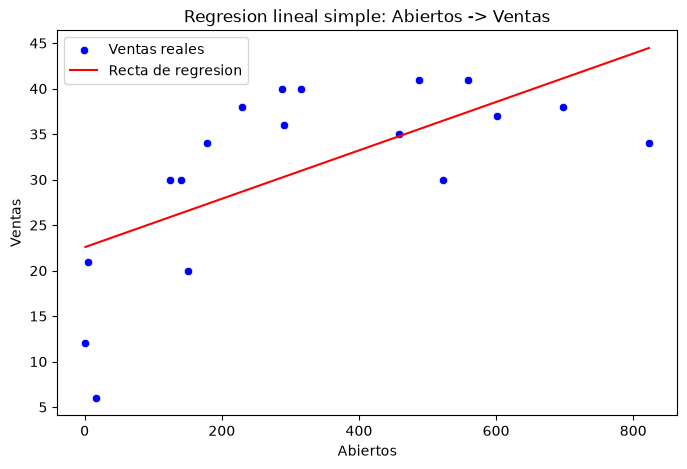

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=mejor_predictor, y="Ventas", data=df, color="blue", label="Ventas reales")
sns.lineplot(x=mejor_predictor, y="Ventas_Predichas", data=df, color="red", label="Recta de regresion")
plt.title(f"Regresion lineal simple: {mejor_predictor} -> Ventas")
plt.legend()
plt.show()